*Предположение: коэффициент $\alpha$ один на весь детектор*

**План работ:**
- функция маскирования чет/нечет;
- функция оценки $\hat{\alpha}$;

**Тестирование:**
- $\hat{\alpha} - \alpha$ в идеальных условиях;
- $\hat{\alpha} - \alpha$ при наличие шума;
- $\hat{\alpha} - \alpha$ при наличие шума и спектральных линий;


In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from spectrumlab.detectors import Detector
from spectrumlab.noises import ConstantNoise
from spectrumlab.peaks.analyte_peaks.shapes import PeakShape
from spectrumlab.peaks.analyte_peaks.shapes.retrieve_shape import retrieve_shape_from_spectrum
from spectrumlab.peaks.blink_peaks import DraftBlinksConfig, draft_blinks
from spectrumlab.spectra import EmittedSpectrum
from spectrumlab.types import Array, Number, R

from spectrumlab_emulations.apertures import Aperture, RectangularApertureShape
from spectrumlab_emulations.apparatus import Apparatus, VoigtApparatusShape
from spectrumlab_emulations.experiments.spectra_emulation import RandomPeakExperiment, RandomPeakExperimentConfig

from plugin.managers.process_manager.filters.scale_filter import estimate_alpha

In [2]:
N_NUMBERS = 2048
N_FRAMES = 1
N_ITERS = 251

EXPOSURE = 100

SHAPE = VoigtApparatusShape(
    width=28,
    asymmetry=+0.1,
    ratio=0.1,
)

MU = -1
SIGMA = .5

In [3]:
def transformer_v1(
    intensity: Array[R],
    background: Array[R],
    alpha: float = 0,
) -> Array[R]:
    assert len(intensity) == len(background)

    number = np.arange(len(intensity))
    effect = alpha
    
    # add background
    value = intensity.copy() + background.copy()

    # add event/odd
    number = np.arange(len(intensity))

    index_even = number % 2 == 0
    value[index_even] = value[index_even] * (1 - effect/2)

    index_odd = number % 2 == 1
    value[index_odd] = value[index_odd] * (1 + effect/2)

    #
    return value


def transformer_v2(
    intensity: Array[R],
    background: Array[R],
    alpha: float = 0,
    beta: float = 0,
    n0: int = 0,
) -> Array[R]:
    assert len(intensity) == len(background)

    number = np.arange(len(intensity))
    effect = alpha + beta*np.abs(number - n0)

    # add background
    value = intensity.copy() + background.copy()
    # value = background.copy()

    # add event/odd
    index_even = number % 2 == 0
    value[index_even] = value[index_even] * (1 - effect[index_even]/2)

    index_odd = number % 2 == 1
    value[index_odd] = value[index_odd] * (1 + effect[index_odd]/2)

    #
    return value

In [4]:
detector = Detector.BLPP2000

experiment = RandomPeakExperiment(
    config=RandomPeakExperimentConfig(
        n_numbers=N_NUMBERS,
        n_frames=N_FRAMES,

        detector=detector,
        apparatus=Apparatus(
            detector=detector,
            shape=SHAPE,
        ),
        aperture=Aperture(
            detector=detector,
            shape=RectangularApertureShape(),
        ),

        exposure=EXPOSURE,
        # position=np.linspace(0, N_NUMBERS, N_ITERS),
        # intensity=np.full(N_ITERS, 1),
        position=np.random.uniform(0, N_NUMBERS, size=(N_ITERS,)),
        intensity=10**np.random.normal(MU, SIGMA, size=(N_ITERS,)),
    ),
)
experiment = experiment.setup(
    verbose=True,
)

100%|██████████| 251/251 [00:00<00:00, 10655.14it/s]


100%|██████████| 251/251 [00:00<00:00, 10291.92it/s]


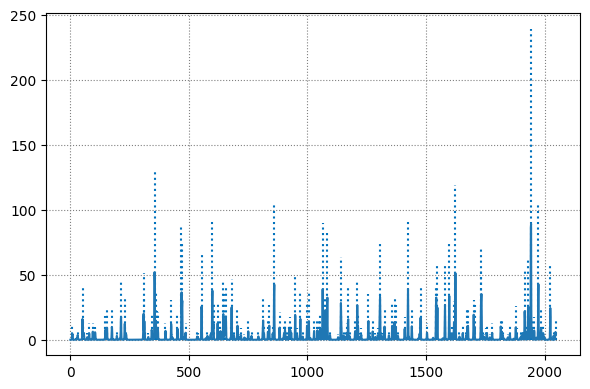

In [5]:
experiment = experiment.setup(
    seed=42,
    verbose=True,
    show=True,
)

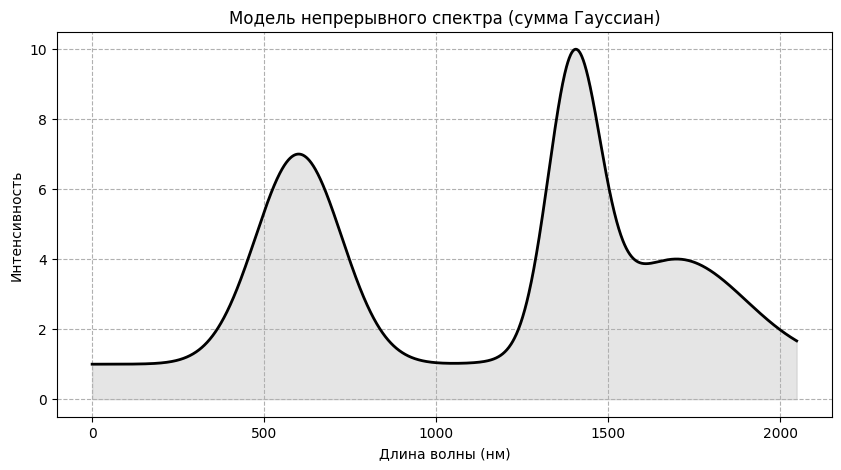

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# number = np.linspace(400, 800, 1000)  # например, нанометры
number = np.arange(N_NUMBERS)

params = [
    {"A": 10, "mu": 2500, "sigma": 75},
    {"A": 6, "mu": 600, "sigma": 125},
    {"A": 8, "mu": 1400, "sigma": 75},
    {"A": 3, "mu": 1700, "sigma": 200},
]

background = np.zeros(len(number), dtype=float) + 1

for p in params:
    line = p["A"] * np.exp(-((number - p["mu"])**2) / (2 * p["sigma"]**2))
    background += line

# spectrum[index_even] = spectrum[index_even] * (1 + alpha/2)
# spectrum[index_odd] = spectrum[index_odd] * (1 - alpha/2)


plt.figure(figsize=(10, 5))
plt.plot(number, background, label='Смоделированный спектр', color='black', lw=2)
plt.fill_between(number, background, alpha=0.2, color='gray')
plt.title("Модель непрерывного спектра (сумма Гауссиан)")
plt.xlabel("Длина волны (нм)")
plt.ylabel("Интенсивность")
plt.grid(True, linestyle='--')
plt.show()


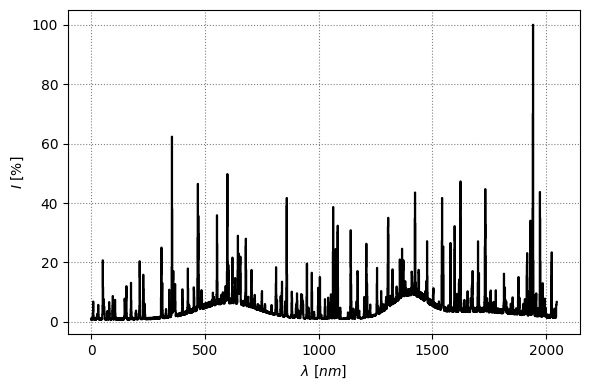

In [7]:
n0 = 1024
alpha = .042
beta = 0.00042
transformer = partial(transformer_v2, n0=n0, alpha=alpha, beta=beta, background=background)

unicorn = experiment.run(
    is_noised=False,
    transformer=transformer,
)

spectrum = experiment.run(
    is_noised=True,
    transformer=transformer,
)
spectrum.show()

In [8]:
peaks = draft_blinks(
    spectrum=spectrum,
    config=DraftBlinksConfig(
        n_counts_min=5,
        except_clipped_peak=False,
        except_sloped_peak=False,
        except_edges=True,
    ),
)

print('Praks total: {}'.format(len(peaks)))

Praks total: 138


In [9]:
mask = np.full(spectrum.n_numbers, True)
for peak in peaks:
    lb, ub = peak.minima
    mask[lb:ub] = False


alpha_hat = estimate_alpha(
    spectrum=spectrum,
    mask=mask,
)
# alpha_hat = 0

alpha_hat

np.float64(0.2562043207990913)

In [10]:
from scipy import optimize


def calculate_loss(
    params: Array[float],
    spectrum: 'Spectrum',
    mask: Array[bool],
) -> float:
    n0, alpha, beta = params

    effect = alpha + beta*np.abs(spectrum.number - n0)

    corrected = spectrum.intensity.copy()
    corrected[0::2] /= 1 - effect[0::2]/2
    corrected[1::2] /= 1 + effect[1::2]/2

    smooth = np.convolve(spectrum.intensity, [.25, .5, .25], mode='same')

    noise = (corrected - smooth)[mask]
    return np.sum(noise**2)


def estimate_params(
    spectrum: 'Spectrum',
    mask: Array[bool],
) -> float:

    index_even = (np.arange(spectrum.n_numbers) % 2 == 0) & mask
    index_odd = (np.arange(spectrum.n_numbers) % 2 == 1) & mask

    R = np.mean(spectrum.intensity[index_even]) / np.mean(spectrum.intensity[index_odd])

    res = optimize.minimize(
        partial(calculate_loss, spectrum=spectrum, mask=mask),
        x0=[
            spectrum.n_numbers//2,
            R,  # alpha
            0,  # beta
        ],
        bounds=[
            (0, spectrum.n_numbers),
            (0, +2),
            (0, +0.1),
        ],
        method='L-BFGS-B',
    )

    return res


res = estimate_params(
    spectrum=spectrum,
    mask=mask,
)

In [11]:
n0, alpha_hat, beta_hat = res['x']

effect = alpha_hat + beta_hat*np.abs(spectrum.number - n0)

In [12]:
n0, (alpha, alpha_hat), (beta, beta_hat)

(np.float64(1023.9999999998616),
 (0.042, np.float64(0.04758870988064085)),
 (0.00042, np.float64(0.0004438534107599262)))

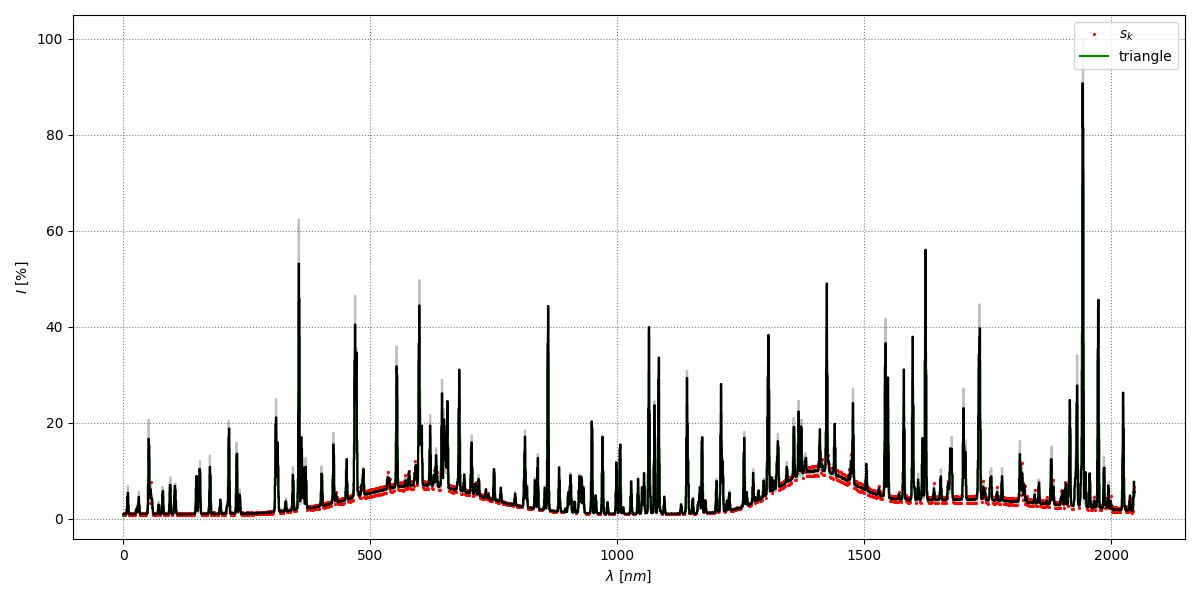

In [15]:
%matplotlib widget

fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

x = spectrum.wavelength
y = spectrum.intensity
ax.step(
    x, y,
    where='mid',
    color='black', alpha=.25,
)

x = spectrum.wavelength[mask]
y = spectrum.intensity[mask]
ax.plot(
    x, y,
    linestyle='none', color='red', alpha=1,
    marker='.', markersize=2.5,
    label='$s_{k}$',
)

x = spectrum.wavelength
y = np.convolve(spectrum.intensity, [.25, .5, .25], mode='same')
ax.step(
    x, y,
    where='mid',
    color='green', alpha=1,
    label='triangle',
)


x = spectrum.wavelength
y_hat = spectrum.intensity.copy()
y_hat[0::2] /= 1 - effect[0::2]/2
y_hat[1::2] /= 1 + effect[1::2]/2
ax.step(
    x, y_hat,
    where='mid',
    color='black',
)

# x = spectrum.wavelength
# y = unicorn.intensity - y_hat
# ax.plot(
#     x, y,
#     linestyle=':',
#     color='black',
# )

ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$I$ [$\%$]')
ax.grid(
    color='grey', linestyle=':',
)

ax.legend(loc='upper right')

plt.show()